In [1]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("Titanic-Dataset.csv")

# 1. Dataset Dimensions
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# 2. Data Types
print("--- Data Types ---")
print(df.dtypes)

# 3. Missing Values (Percentage)
# Calculating the percentage of missing values dictates whether to drop or impute a feature
print("\n--- Missing Values (%) ---")
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_percent[missing_percent > 0]) # Only show columns with missing data

# 4. Duplicate Rows
# Duplicates can cause data leakage and artificially inflate model performance
print(f"\n--- Duplicate Rows ---")
print(f"Total duplicates: {df.duplicated().sum()}")

# 5. Numerical Summary
# Transposing (.T) the describe matrix makes it much easier to read
print("\n--- Numerical Feature Summary ---")
display(df.describe().T)

# 6. Categorical Summary
# Including 'object' isolates text categories to check cardinality (number of unique values)
print("\n--- Categorical Feature Summary ---")
display(df.describe(include=['object']).T)

Dataset Shape: 891 rows, 12 columns

--- Data Types ---
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

--- Missing Values (%) ---
Age         19.87
Cabin       77.10
Embarked     0.22
dtype: float64

--- Duplicate Rows ---
Total duplicates: 0

--- Numerical Feature Summary ---


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



--- Categorical Feature Summary ---


,count,unique,top,freq
Name,891,891,"Dooley, Mr. Patrick",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


In [3]:
# 2. Handle Missing Values
# Drop 'Cabin' due to excessive missing data
df = df.drop(columns=['Cabin'])

# Impute numerical 'Age' with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Impute categorical 'Embarked' with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("--- Missing Values After Imputation ---")
print(df.isnull().sum())

# 3. Convert Categorical Features into Numerical (Encoding)
# Drop non-predictive unique identifiers
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

# One-hot encode 'Sex' and 'Embarked', dropping the first category to avoid multicollinearity
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

print("\n--- Data Snapshot After Encoding ---")
display(df.head())

--- Missing Values After Imputation ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

--- Data Snapshot After Encoding ---


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


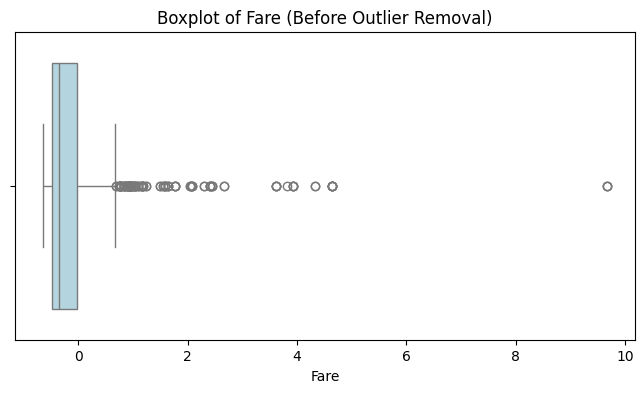

Original dataset shape: (891, 9)
Cleaned dataset shape: (775, 9)


In [4]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Standardize numerical features
scaler = StandardScaler()
numerical_cols = ['Age', 'Fare']
# Scales the data so the mean is 0 and standard deviation is 1
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# 5. Visualize and remove outliers
# Generate the required boxplot for the 'Fare' column
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Fare'], color='lightblue')
plt.title('Boxplot of Fare (Before Outlier Removal)')
plt.show()

# Calculate the Interquartile Range (IQR) to filter out statistical outliers
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataset to keep only the values within the IQR boundaries
df_cleaned = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)]

print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")